# Rotating coordinate system and visualize  point clouds

Author Hina Suzuki, FreeFall Aerospace. Inc \
hsuzuki@freefallaerospace.com 

This notebook provide a function perform coordinate rotation based on singular value decomposition (SVD) of 3D vectors, and visualize those into 2D plots. One of the useage for this is to visualize and analyze points captured by Photogrammetry camera. 

In [1]:
# !pip install numpy
# !pip install 
# !pip install scipy

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

## Read in data

In [3]:
date = '04-02-26'
filename = f'Photogrammetry-{date}.txt'


arr = np.loadtxt("Data/"+filename, usecols=range(1, 8))

In [4]:
x = arr[:,0]
y = arr[:,1]
z = arr[:,2]

## Visualize as is

In [7]:
def vis(x,y,z, ind=False, asp=False, Verdose=False): 
    '''This fucntion is to plot 3D vector in 3D plot and XY, XZ, YZ slices.
    Input:
        x,y,z (array) 
        ind (Boolean) : True, show index of points in XY slice
        asp (Boolean) : True, set aspect ration to be 'equal' in  
    Output: '''
    fig = plt.figure(figsize=(12, 10))

 
    # 3D plot
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(x, y, z, c='blue')
    # ax1.set_title('3D Plot')
    ax1.set_xlabel('X (mm)')
    ax1.set_ylabel('Y (mm)')
    ax1.set_zlabel('Z (mm)')

    # XY plane
    ax2 = fig.add_subplot(222)
    ax2.scatter(x, y, c='red')
    if ind:
        for i, (xi, yi) in enumerate(zip(x, y)):
            ax2.text(xi, yi, str(i), fontsize=9, color='black')
    ax2.set_xlabel('X (mm)')
    ax2.set_ylabel('Y (mm)')
    ax2.set_aspect("equal")
    ax2.grid()

    # XZ plane
    ax3 = fig.add_subplot(223)
    ax3.scatter(x, z)
    ax3.set_xlabel('X (mm)')
    ax3.set_ylabel('Z (mm)')
    ax3.grid()

    # YZ plane
    ax4 = fig.add_subplot(224)
    ax4.scatter(y, z, c='purple')
    ax4.set_xlabel('Y (mm)')
    ax4.set_ylabel('Z (mm)')
    ax4.grid()

    if asp: 
        ax3.set_ylim(min(z)*0.5, max(z)*1.3)
        ax4.set_ylim(min(z)*0.5, max(z)*1.3)

    if Verdose: 
        ax1.set_title(f"Maximum difference: {max(z)-min(z):.4f} (mm)")
        fig.savefig(f"figs/vis-{date}.png")


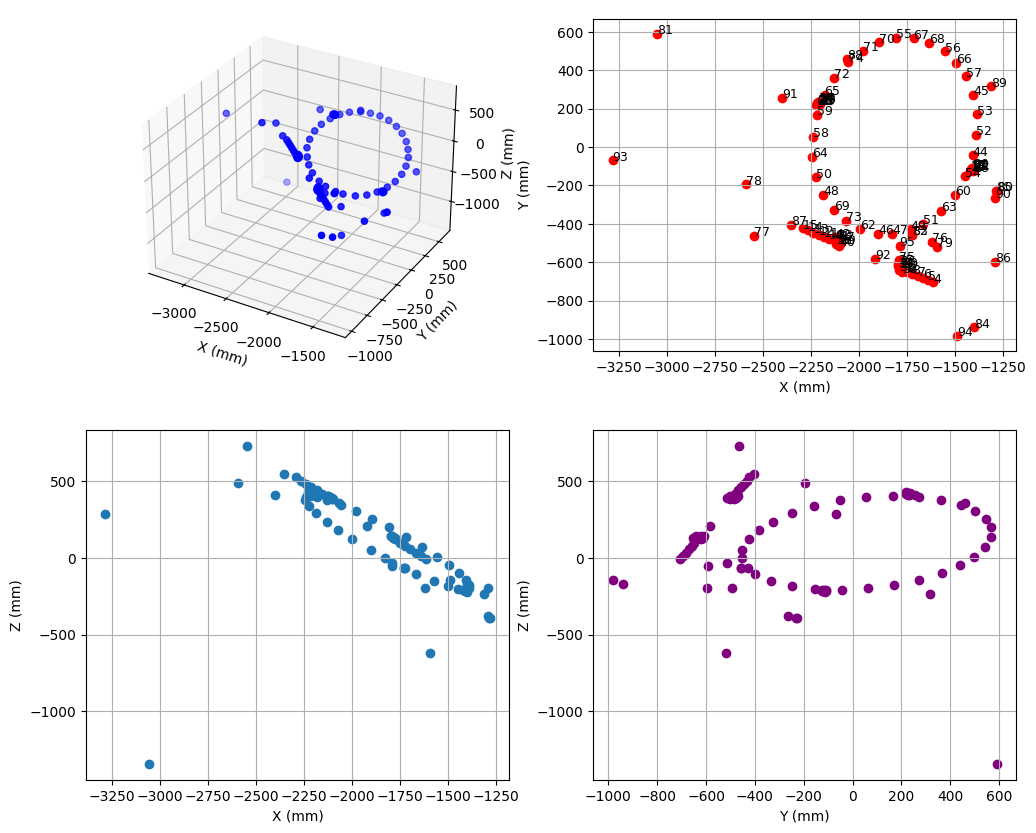

In [8]:
vis(x,y,z, ind=True)

## Get reference points

In [9]:
xb = x[4:16]
yb = y[4:16]
zb = z[4:16]

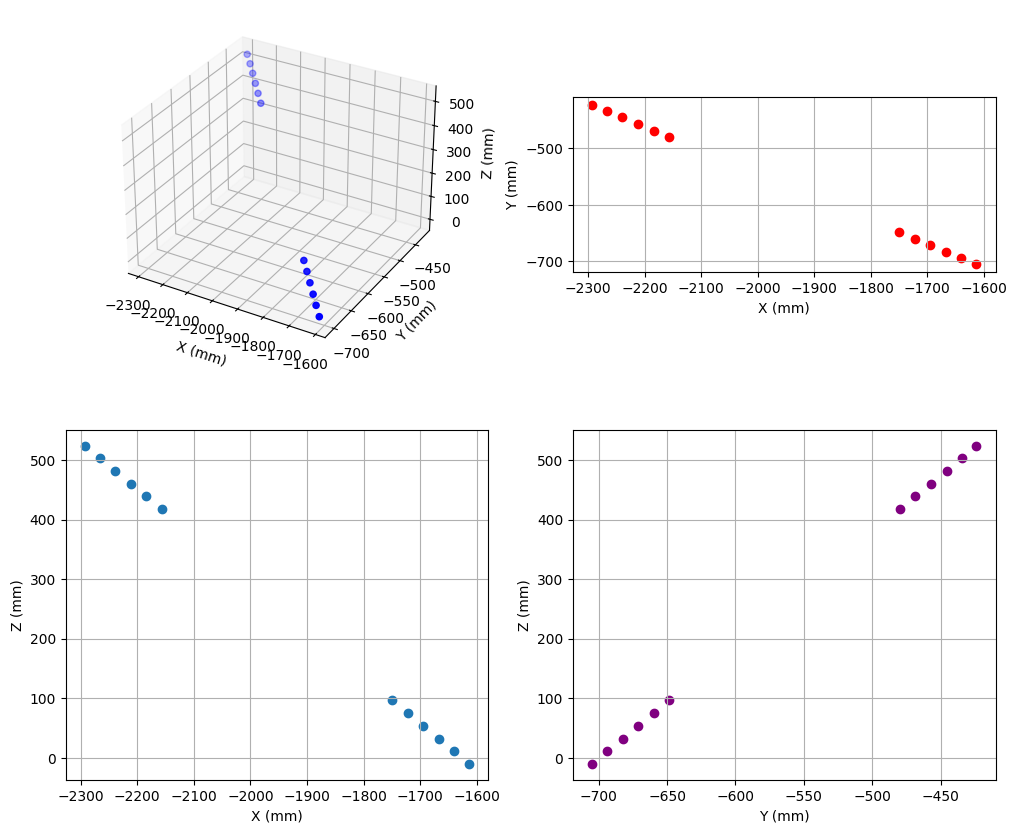

In [10]:
vis(xb, yb, zb)

## Get points of interest

In [11]:
xp = x[44:75]
yp = y[44:75]
zp = z[44:75]

In [12]:
xp = np.delete(xp, 17)
yp = np.delete(yp, 17)
zp = np.delete(zp, 17)

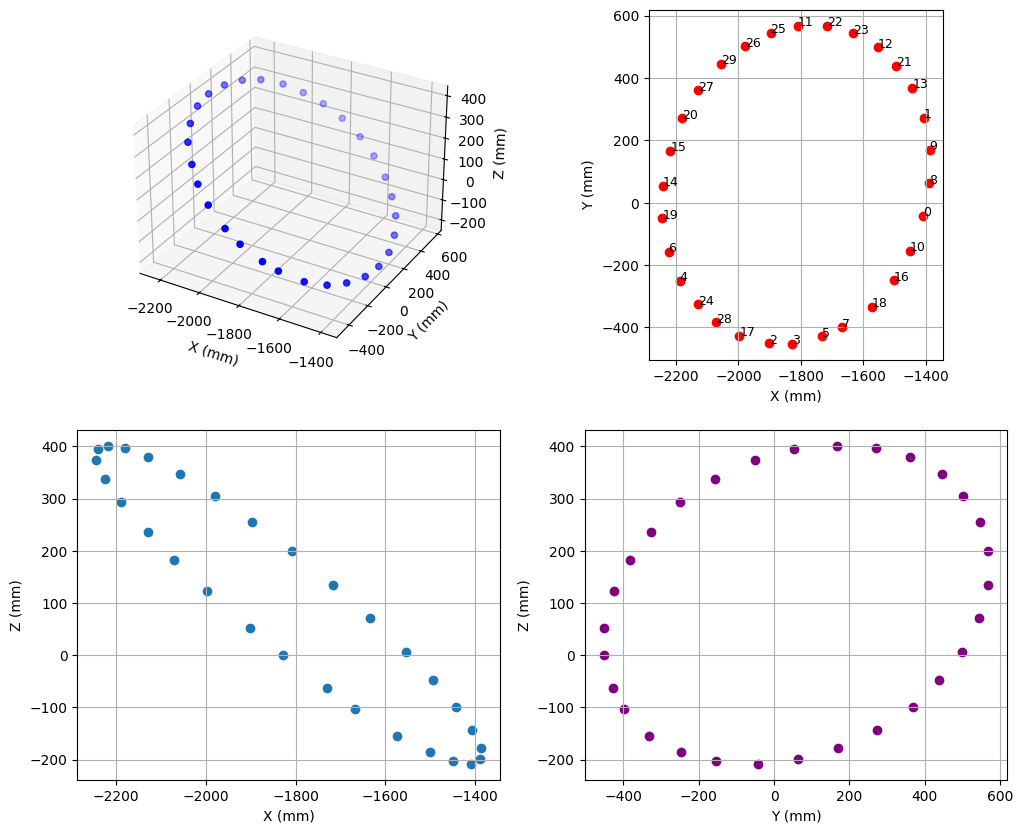

In [13]:
vis(xp, yp, zp, ind=True)

## Set up SVD 

In [14]:
def svd_rotate(ref, pts):
    """
    Singular Value Decompision on reference points xr, yr, zr and rotate coordinate of all points
    """

    # references 
    mean_ref = ref.mean(axis=0)
    ref_centered = ref - mean_ref

    U, S, Vt = np.linalg.svd(ref_centered, full_matrices=False)

    #rottation matrix bases on 
    R = Vt.T   

    rotated_ref = ref_centered @ R

    # other points
    pts_centered = pts - mean_ref

    rotated_pts = pts_centered @ R

    Xr, Yr, Zr = rotated_ref.T
    X, Y, Z = rotated_pts.T

    return Xr, Yr, Zr, X, Y, Z, R, mean_ref


In [15]:
ref = np.vstack([xb, yb, zb]).T  
pts = np.vstack([xp, yp, zp]).T 

In [16]:
Xr, Yr, Zr, X, Y, Z, _, _ = svd_rotate(pts, ref)

In [17]:
x, y, z = np.append(Xr, X), np.append(Yr, Y), np.append(Zr, Z)

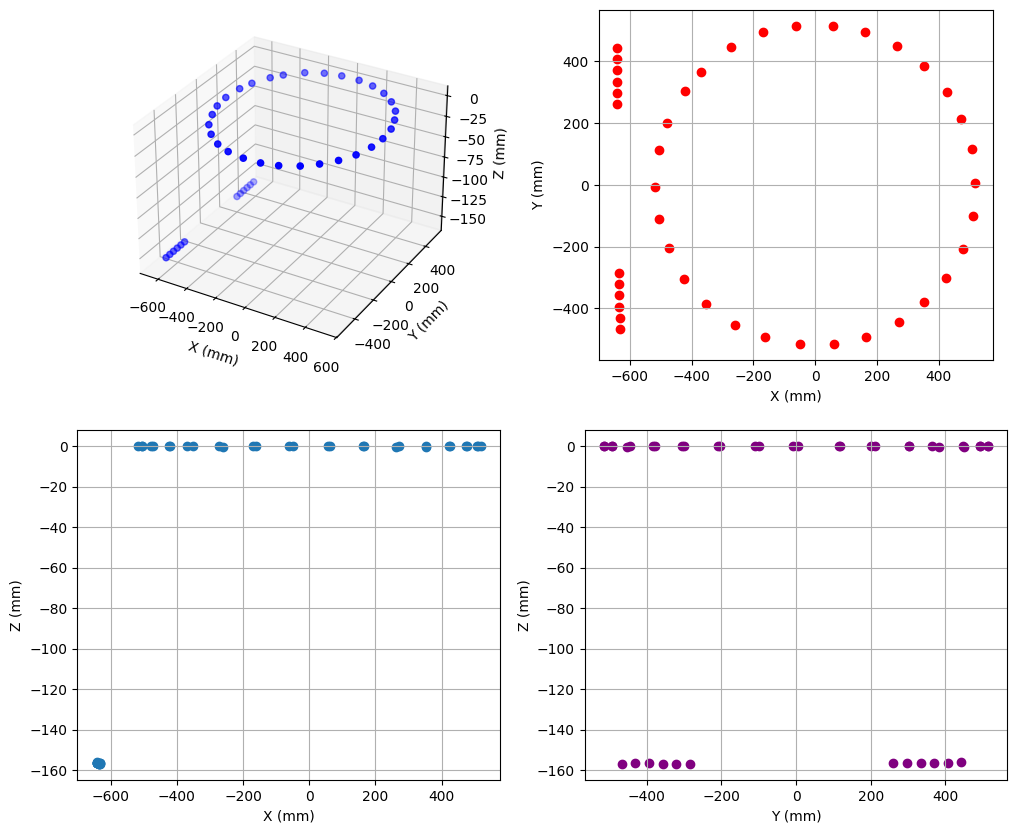

In [18]:
vis(x,y,z)

In [19]:
## To match XY on physical system, interchange labelings
x_p = Yr
y_p = Xr
z_p = Zr

## Interpolation and surface fit

In [20]:
from scipy.interpolate import griddata

def surfacefit(x, y, z, method='cubic', gridsize=200):
    
    xi = np.linspace(min(x), max(x), gridsize)
    yi = np.linspace(min(y), max(y), gridsize)
    Xg, Yg = np.meshgrid(xi, yi)

    Zg = griddata(
        points=np.column_stack((x, y)),
        values=z,
        xi=(Xg, Yg),
        method=method
    )

    return Xg, Yg, Zg


In [21]:
Xg, Yg, Zg = surfacefit(x_p, y_p, z_p, method='cubic')

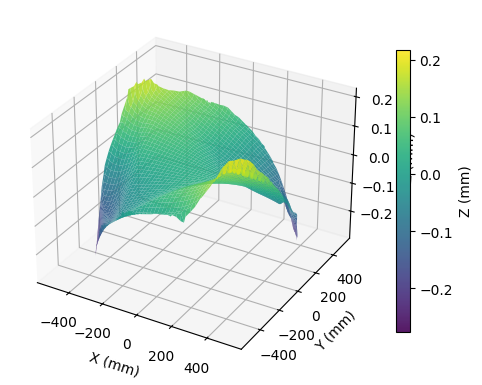

In [22]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.9)
# ax.scatter(Xr, Yr, Zr, color='red', s=40)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')

fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()
fig.savefig(f"figs/surfacefit-{date}.png")


c:\Users\ual-laptop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


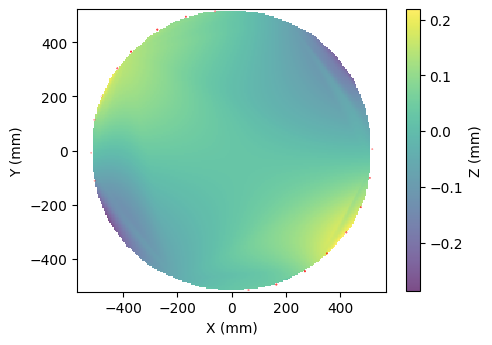

In [23]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

surf = ax.pcolormesh(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.7)
ax.scatter(Xr, Yr, Zr, color='red')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')

ax.set_aspect("equal")
fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()
fig.savefig(f"figs/intensitymap-{date}.png")


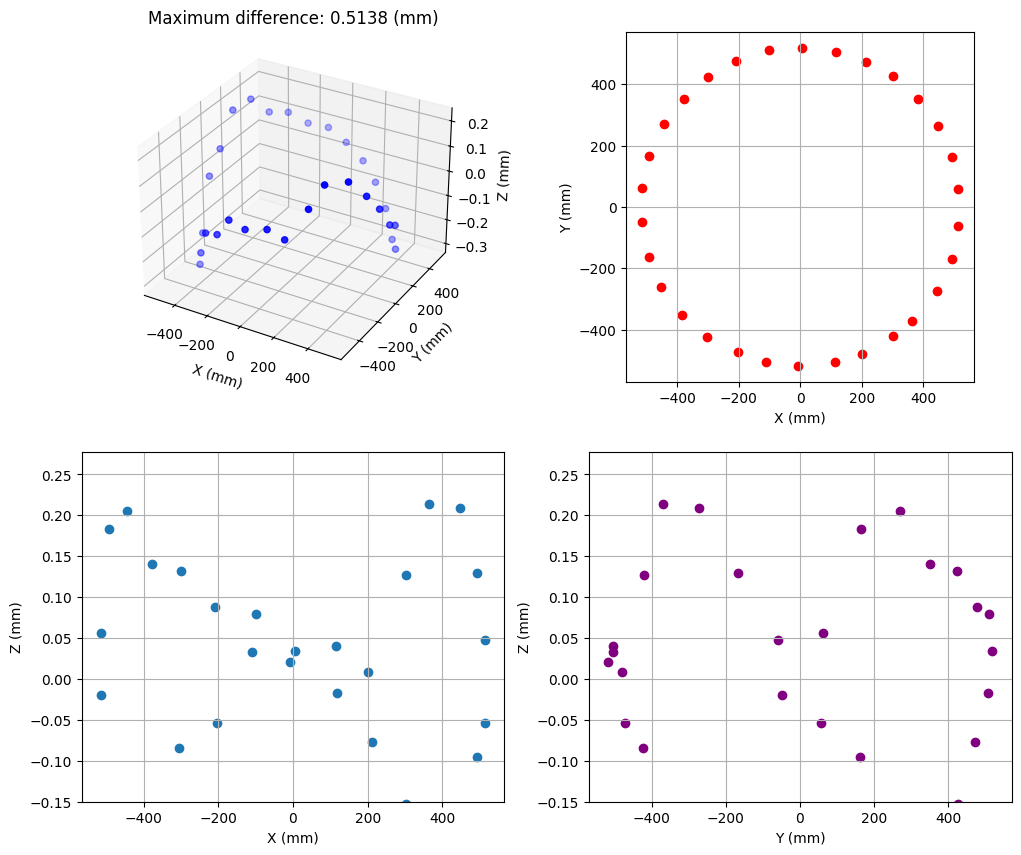

In [24]:
vis(x_p, y_p, z_p, asp=True, Verdose=True)